

# Підготовка даних до аналізу






<h2>Мета</h2>

Ознайомитись з методикою первинної обробки даних. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати структуру завантажених даних
* Виправляти формати даних
* Знаходити та заповнювати пропуски в даних
* Знаходити викиди та некоректні значення
* Будувати прості візуалізації




<a name="task"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>





1. Скачати дані із файлу <a href="https://drive.google.com/file/d/1Vz4Kkbu4HVMuBKsOz_5gq3C8jYYXA89d/view?usp=drive_link" target="_blank">'Data2.csv'</a>. Записати дані у dataframe. Дослідити структуру даних.
2. Виправити помилки в даних.
3. Заповнити пропуски.
4. Додати стовпчик із щільністю населення.
5. Побудувати діаграми розмаху та гістограми.


<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити структуру даних</p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from pandas import read_csv

DATA_PATH = 'data/Data.csv'

df = read_csv(DATA_PATH, sep=';', encoding='cp1252')

<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
DATA_PATH = 'data/Data2.csv'

# Зчитуємо файл із заданим розділяючим символом ";"
df = pd.read_csv(DATA_PATH, sep=';')

'''
Зауваження: попередній код зчитування з файлу підходить для
файлів з кодуванням utf-8. Проте файл Data2.csv спочатку мав інше
кодування. Дане кодування потрібно вказати в якості параметру:
    
'''

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')


```
</details>




Досліджую структуру даних


In [2]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df.head(20)

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
0,Afghanistan,South Asia,"561,7787463",34656032.0,"9809,225",652860
1,Albania,Europe & Central Asia,"4124,98239",2876101.0,"5716,853",28750
2,Algeria,Middle East & North Africa,"3916,881571",40606052.0,"145400,217",2381740
3,American Samoa,East Asia & Pacific,"11834,74523",55599.0,NaN,200
4,Andorra,Europe & Central Asia,"36988,62203",77281.0,"462,042",470
5,Angola,Sub-Saharan Africa,"3308,700233",28813463.0,"34763,16",1246700
6,Antigua and Barbuda,Latin America & Caribbean,"14462,17628",100963.0,"531,715",440
7,Argentina,Latin America & Caribbean,"12440,32098",43847430.0,"204024,546",2780400
8,Armenia,Europe & Central Asia,"3614,688357",2924816.0,"5529,836",29740
9,Aruba,Latin America & Caribbean,NaN,104822.0,"872,746",180


In [3]:
df.dtypes

Country Name       object
Region             object
GDP per capita     object
Populatiion       float64
CO2 emission       object
Area               object
dtype: object

In [4]:
df.describe(include='all')

,Country Name,Region,GDP per capita,Populatiion,CO2 emission,Area
count,217,217,190,2.160000e+02,205,217
unique,217,7,190,NaN,202,213
top,Afghanistan,Europe & Central Asia,"561,7787463",NaN,"6318,241",460
freq,1,58,1,NaN,2,3
mean,NaN,NaN,NaN,3.432256e+07,NaN,NaN
std,NaN,NaN,NaN,1.347600e+08,NaN,NaN
min,NaN,NaN,NaN,1.109700e+04,NaN,NaN
25%,NaN,NaN,NaN,7.900265e+05,NaN,NaN
50%,NaN,NaN,NaN,6.221590e+06,NaN,NaN
75%,NaN,NaN,NaN,2.350337e+07,NaN,NaN


Бачу наступні проблеми в даних:
1. Запис нецілих чисел у різних колонках відрізняється (кома, крапка) 
2. Неправильний тип у більшості стовпців
3. Відʼємні значення 
4. Є пропущені значення в "GDP per capital", "CO2 emission", "Population"




<a name="task2"></a> <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2"> Завдання  #2: </h2>

<p>Виправити помилки в даних</p>
</div>


<b>Проблема 1: Запис нецілих чисел у різних колонках відрізняється (кома, крапка) </b>
<p>
    Для виправлення приведу записи до одного виду – запис через крапку.
</p>

In [5]:
headers = [
    'country_name',
    'region',
    'gdp_per_capita',
    'population',
    'co2_emission',
    'area',
]

df.columns = headers

float_columns = [
    'co2_emission',
    'area',
]

for column in float_columns:
    df[column] = df[column].str.replace(',', '.')

integer_columns = [
    'gdp_per_capita',
]

for column in integer_columns:
    df[column] = df[column].str.replace(',', '')

    
df.head(20)

,country_name,region,gdp_per_capita,population,co2_emission,area
0,Afghanistan,South Asia,5617787463,34656032.0,9809.225,652860
1,Albania,Europe & Central Asia,412498239,2876101.0,5716.853,28750
2,Algeria,Middle East & North Africa,3916881571,40606052.0,145400.217,2381740
3,American Samoa,East Asia & Pacific,1183474523,55599.0,NaN,200
4,Andorra,Europe & Central Asia,3698862203,77281.0,462.042,470
5,Angola,Sub-Saharan Africa,3308700233,28813463.0,34763.16,1246700
6,Antigua and Barbuda,Latin America & Caribbean,1446217628,100963.0,531.715,440
7,Argentina,Latin America & Caribbean,1244032098,43847430.0,204024.546,2780400
8,Armenia,Europe & Central Asia,3614688357,2924816.0,5529.836,29740
9,Aruba,Latin America & Caribbean,NaN,104822.0,872.746,180


<b>Проблема 2: Неправильний тип у більшості стовпців</b>
<p>
    Для виправлення зміню тип даних на підходящий.
</p>

In [6]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from numpy import nan

df.head()

df.replace(r'^\s*$', nan, regex=True, inplace=True)

df[['country_name', 'region']] =  df[['country_name', 'region']].astype('string')
df[['gdp_per_capita', 'co2_emission', 'area', 'population']] = df[['gdp_per_capita', 'co2_emission', 'area', 'population']].astype('float')

# колонки population та gdp_per_capita мають бути цілими числами, але оскільки в них є NaN, то вони мають тип float для зручності подальших операцій. 
# тип колонок змінимо пізніше

df.dtypes



country_name      string[python]
region            string[python]
gdp_per_capita           float64
population               float64
co2_emission             float64
area                     float64
dtype: object

<b>Проблема 2: Відʼємні значення </b>
<p>
    Для виправлення візьму абсолютне значення записів із відʼємним числом.
</p>

In [7]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
columns_with_negative_values = [
    'area',
    'gdp_per_capita',
]

for column in columns_with_negative_values:
    df[column] = df[column].apply(lambda x: abs(x) if x < 0 else x)

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3"> Завдання  #3: </h2>

<p>Заповнити пропуски</p>
</div>


<b>Проблема 3: Є пропущені значення в "GDP per capital", "CO2 emission", "Population"</b>

In [8]:

# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
missing_data = df.isnull()

for column in missing_data.columns.values.tolist():
    print(missing_data[column].value_counts(), end='\n\n')


country_name
False    217
Name: count, dtype: int64

region
False    217
Name: count, dtype: int64

gdp_per_capita
False    190
True      27
Name: count, dtype: int64

population
False    216
True       1
Name: count, dtype: int64

co2_emission
False    205
True      12
Name: count, dtype: int64

area
False    217
Name: count, dtype: int64



<p>
    Для виправлення зроблю наступне:
</p>
<ul>
    <li> gdp_per_capita: 27 відсутніх значень. заміню їх медіаною, щоб не було помітного впливу на загальну статистику</li>
    <li> population: 1 відсутнє значення. заповню даними із зовнішніх ресурсів</li>
    <li> co2_emission: 12 відсутніх значень. видалю їх, оскільки це те – що ми хочемо передбачити </li>
<ul>

In [9]:
# gdp_per_capita
df['gdp_per_capita'] = df['gdp_per_capita'].fillna(df['gdp_per_capita'].median())


# population
eritrea = df[df['country_name'] == 'Eritrea']

eritrea_population = 3_579_283  # https://www.worldometers.info/world-population/eritrea-population/

df[df['country_name'] == 'Eritrea'] = df[df['country_name'] == 'Eritrea'].fillna(eritrea_population)


# co2_emission 
df.dropna(subset=['co2_emission'], axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)


Досліджую структуру даних, чи всі пропуски заповнено


In [10]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
missing_data = df.isnull()

for column in missing_data.columns.values.tolist():
    print(missing_data[column].value_counts(), end='\n\n')

country_name
False    205
Name: count, dtype: int64

region
False    205
Name: count, dtype: int64

gdp_per_capita
False    205
Name: count, dtype: int64

population
False    205
Name: count, dtype: int64

co2_emission
False    205
Name: count, dtype: int64

area
False    205
Name: count, dtype: int64



<p> 
На даному етапі всі пропуски заповнено / видалено, тому ми можемо привести колонку до правильного типу
</p>

In [11]:
df[['population', 'gdp_per_capita']] = df[['population', 'gdp_per_capita']].astype('int')

df.dtypes


country_name      string[python]
region            string[python]
gdp_per_capita             int64
population                 int64
co2_emission             float64
area                     float64
dtype: object

 <a name="task4"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4"> Завдання  #4: </h2>

<p>Додати стовпчик із щільністю населення</p>
</div>


Щільність населення розрахую по формулі кількість населення поділена на площу країни. Додам результат у новий стовпчик "population_density"


In [12]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df['population_density'] = df['population'] / df['area']
df.head(20)

,country_name,region,gdp_per_capita,population,co2_emission,area,population_density
0,Afghanistan,South Asia,5617787463,34656032,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,412498239,2876101,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916881571,40606052,145400.217,2381740.0,17.048902
3,Andorra,Europe & Central Asia,3698862203,77281,462.042,470.0,164.427660
4,Angola,Sub-Saharan Africa,3308700233,28813463,34763.160,1246700.0,23.111786
5,Antigua and Barbuda,Latin America & Caribbean,1446217628,100963,531.715,440.0,229.461364
6,Argentina,Latin America & Caribbean,1244032098,43847430,204024.546,2780400.0,15.770188
7,Armenia,Europe & Central Asia,3614688357,2924816,5529.836,29740.0,98.346200
8,Aruba,Latin America & Caribbean,3675459700,104822,872.746,180.0,582.344444
9,Australia,East Asia & Pacific,4975531548,24127159,361261.839,7741220.0,3.116713


<a name="task5"></a>
 <div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5"> Завдання  #5: </h2>

<p>Побудувати діаграми розмаху та гістограми</p>
</div>


Для побудови графіків скористайтесь бібліотекою Matplotlib. Спробуйте погратись з кольорами, розмірами та підписами.


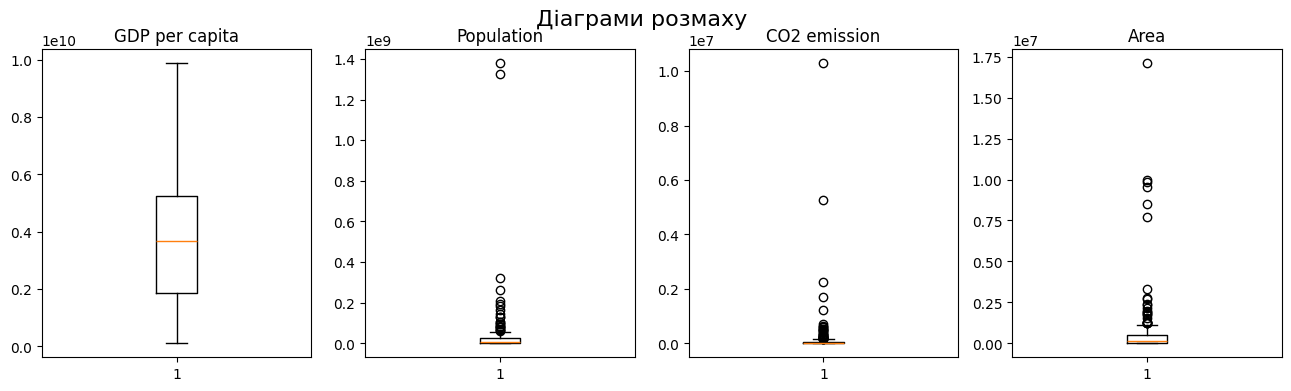

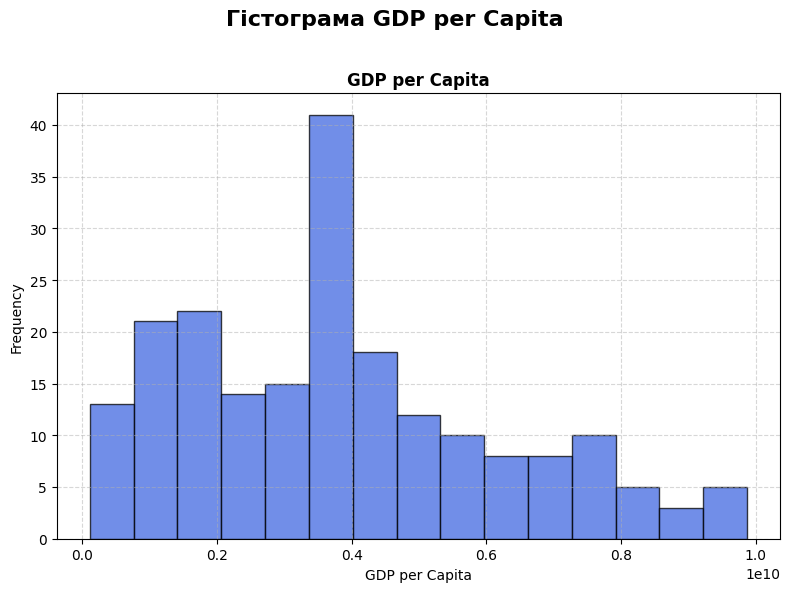

In [13]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['gdp_per_capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['co2_emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['area'])

plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Гістограма GDP per Capita', fontsize=16, fontweight='bold')

ax.hist(df['gdp_per_capita'], bins=15, color='royalblue', edgecolor='black', alpha=0.75)
ax.set_title('GDP per Capita', fontsize=12, fontweight='bold')
ax.set_xlabel('GDP per Capita', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<details><summary>Натисніть тут, щоб побачити підказку</summary>

```python
# Імпортуємо бібліотеку Matplotlib
import matplotlib.pyplot as plt
    
# діаграми розмаху для "GDP per capita", "Population", "CO2 emission" та "Area"

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

fig.suptitle('Діаграми розмаху', fontsize=16)

axs[0].set_title('GDP per capita')
axs[0].boxplot(df['GDP per capita'])

axs[1].set_title('Population')
axs[1].boxplot(df['Population'])

axs[2].set_title('CO2 emission')
axs[2].boxplot(df['CO2 emission'])

axs[3].set_title('Area')
axs[3].boxplot(df['Area'])

plt.show()

```
</details>




<a name="task6"></a>
 <div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. Яка країна має найбільший ВВП на людину (GDP per capita)?
2. Яка країна має найменшу площу?
3. Знайдіть країну з найбільшою щільністю населення у світі? У Європі та центральній Азії?
4. Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.



<details><summary>Натисніть тут, щоб побачити підказку</summary>
    
Скористайтесь методами <code>loc()</code> для повернення зрізу датафрейму, <code>idxmax()</code> для повернення номера рядка з найбільшим значенням якогось показника у стовпці та <code>idxmin()</code> для повернення номера рядка з найменшим значенням якогось показника у стовпці
    
```python
df.loc[df['GDP per capita'].idxmax()]

```
    
Гарно оформити виведення інформації допоможе <code>print()</code>  
```python
print('\n' + df.loc[df['GDP per capita'].idxmax(), 'Country Name'] + ' має найбільший ВВП на людину')
```   
  
</details>


In [14]:

# Яка країна має найбільший ВВП на людину (GDP per capita)?
print('\n' + df.loc[df['gdp_per_capita'].idxmax(), 'country_name'] + ' має найбільший ВВП на людину')

# Яка країна має найменшу площу (area)?
print('\n' + df.loc[df['area'].idxmin(), 'country_name'] + ' має найменшу площу')

# Знайдіть країну з найбільшою щільністю населення у світі
print('\n' + df.loc[df['population_density'].idxmax(), 'country_name'] + ' має найбільшу щільність населення у світі')

# Знайдіть країну з найбільшою щільністю населення у Європі та центральній Азії
europe_central_asia = df[df['region'] == 'Europe & Central Asia']
print('\n' + europe_central_asia.loc[europe_central_asia['population_density'].idxmax(), 'country_name'] + ' має найбільшу щільність населення у Європі та центральній Азії')

# Покажіть топ 5 країн та 5 останніх країн по ВВП на людину.

top_5_gdp_per_capita = df.nlargest(5, 'gdp_per_capita')
last_5_gdp_per_capita = df.nsmallest(5, 'gdp_per_capita')

print('\nТоп 5 країн по ВВП на людину:')
print(top_5_gdp_per_capita[['country_name', 'gdp_per_capita']])

print('\n5 останніх країн по ВВП на людину:')
print(last_5_gdp_per_capita[['country_name', 'gdp_per_capita']])



Maldives має найбільший ВВП на людину

Gibraltar має найменшу площу

Macao SAR, China має найбільшу щільність населення у світі

Gibraltar має найбільшу щільність населення у Європі та центральній Азії

Топ 5 країн по ВВП на людину:
    country_name  gdp_per_capita
116     Maldives      9875278428
121    Mauritius      9630944028
157      Senegal      9527683234
151      Romania      9522771041
172    St. Lucia      9364821525

5 останніх країн по ВВП на людину:
    country_name  gdp_per_capita
188       Turkey       108626004
44    Costa Rica       118246381
83       Hungary       128200882
109    Lithuania       149007789
43   Congo, Rep.       152824472


Збережіть дані у новий файл 'clean_data2.csv':


In [15]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
# Збережіть дані у новий файл 'clean_data2.csv':

CLEAN_DATA_PATH = 'data/clean_data.csv'

df.to_csv(CLEAN_DATA_PATH, index=False, sep=';', encoding='utf-8')


<h2>Виконав студент групи ІП-33  <br>Соколов Олександр</h2>
